In [4]:
# importing all packages and setting plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline
import warnings
import geopandas as gpd
warnings.filterwarnings('ignore')

In [5]:
# loading data to dataframe with its specific encoding (latin1)
df=pd.read_csv('results.csv',low_memory=False, encoding='latin1')
df_scores = pd.read_csv("CountryScoreRank.csv", encoding='latin1')
country_codes = pd.read_csv("country_codes.csv", encoding='latin1')

In [6]:
dfi_psi=df[['CNT','CNTSCHID','OECD','ADMINMODE','SC001Q01TA','SC016Q01TA','SC016Q03TA','SC017Q01NA','SC017Q05NA','SC017Q07NA',
            'SC155Q01HA','SC156Q08HA','SC154Q01HA','SC037Q01TA','SC037Q02TA','SC061Q02TA','SC061Q06TA','SC018Q01TA01',
            'SC018Q05NA01','SC159Q01HA','SC150Q01IA','SC052Q01NA','SCHSIZE','TOTAT','CLSIZE','SC053Q02TA'
           ]].copy()

# renaming variables of interest to more descriptive names
dfi_psi.rename(columns={'OECD':'CountryStatus','ADMINMODE': 'ModeofRespondent','CNTSCHID':'SchoolId',
                        'SC001Q01TA':'LocationOfSchool','SC016Q01TA':'GovtFunding','SC016Q03TA':'Sponsorship',
                        'SC017Q01NA':'InAdequateStaff','SC017Q05NA':'InAdequateMaterial','SC017Q07NA':'InAdequateMaterial',
                        'SC155Q01HA':'DigitalDevices','SC156Q08HA':'EvaluateInstructionMaterial',
                        'SC154Q01HA':'AssessmentAsGuideToStudent','SC037Q01TA':'QualityAssurance_Internal',
                        'SC037Q02TA':'QualityAssurance_External','SC061Q02TA':'SkippingClasses',
                        'SC061Q06TA':'TeachersNotMeetingStudentNeeds','SC018Q01TA01':'TeachersInTotal',
                        'SC018Q05NA01':'TeachersWithBSc','SC159Q01HA':'HostVisitingTeachers',
                        'SC150Q01IA':'ReceiveAdditionalPeriods','SC052Q01NA':'StudyRoomBySchool',
                        'TOTAT':'TeachersTotal','SC053Q02TA':'ExtraActivitiesOffered'
                       },inplace=True)
                        

In [7]:
# overview of the null variables
perRowMissing = dfi_psi.isnull().sum(axis=1)
totalRow= perRowMissing.sum()
total_records = dfi_psi.shape[0]
totalRow

46181

In [8]:
Datacleaned = dfi_psi.dropna()
Datacleaned.columns

Index(['CNT', 'SchoolId', 'CountryStatus', 'ModeofRespondent',
       'LocationOfSchool', 'GovtFunding', 'Sponsorship', 'InAdequateStaff',
       'InAdequateMaterial', 'InAdequateMaterial', 'DigitalDevices',
       'EvaluateInstructionMaterial', 'AssessmentAsGuideToStudent',
       'QualityAssurance_Internal', 'QualityAssurance_External',
       'SkippingClasses', 'TeachersNotMeetingStudentNeeds', 'TeachersInTotal',
       'TeachersWithBSc', 'HostVisitingTeachers', 'ReceiveAdditionalPeriods',
       'StudyRoomBySchool', 'SCHSIZE', 'TeachersTotal', 'CLSIZE',
       'ExtraActivitiesOffered'],
      dtype='object')

In [9]:
country_codes.columns

Index(['Code', 'Country/Region'], dtype='object')

In [10]:
# Calculate the average score
df_scores['AverageScore'] = df_scores[['Reading', 'Mathematics', 'Science']].mean(axis=1).round(2)
# Renaming the column
df_scores = df_scores.rename(columns={'ï»¿CNT': 'CNT'})
df_scores = df_scores.rename(columns={'Country': 'Countrys'})
df_scores

,CNT,Countrys,Reading,Mathematics,Science,AverageScore
0,ALB,Albania,405.0,437.0,417.0,419.67
1,ARG,Argentina,402.0,379.0,404.0,395.00
2,AUS,Australia,503.0,491.0,503.0,499.00
3,AUT,Austria,484.0,499.0,490.0,491.00
4,QCI,B-S-J-Z (China),555.0,591.0,590.0,578.67
...,...,...,...,...,...,...
77,ARE,United Arab Emirates,432.0,435.0,434.0,433.67
78,GBR,United Kingdom,504.0,502.0,505.0,503.67
79,USA,United States,505.0,478.0,502.0,495.00
80,URY,Uruguay,427.0,418.0,426.0,423.67


In [11]:
# Creating pisa_score table by merging in the country info
pisa_score = dfi_psi.merge(df_scores, how = 'left', on ='CNT')
Clean_Data = pisa_score.dropna()
Clean_Data

,CNT,SchoolId,CountryStatus,ModeofRespondent,LocationOfSchool,GovtFunding,Sponsorship,InAdequateStaff,InAdequateMaterial,InAdequateMaterial,...,StudyRoomBySchool,SCHSIZE,TeachersTotal,CLSIZE,ExtraActivitiesOffered,Countrys,Reading,Mathematics,Science,AverageScore
2,ALB,800004.0,0.0,2.0,1.0,100.0,0.0,1.0,2.0,2.0,...,1.0,205.0,21.0,18.0,1.0,Albania,405.0,437.0,417.0,419.67
5,ALB,800007.0,0.0,2.0,1.0,100.0,0.0,1.0,3.0,2.0,...,1.0,45.0,9.5,13.0,1.0,Albania,405.0,437.0,417.0,419.67
7,ALB,800009.0,0.0,2.0,4.0,0.0,100.0,2.0,2.0,2.0,...,2.0,823.0,48.5,28.0,1.0,Albania,405.0,437.0,417.0,419.67
14,ALB,800016.0,0.0,2.0,1.0,70.0,10.0,2.0,3.0,4.0,...,2.0,47.0,7.0,13.0,1.0,Albania,405.0,437.0,417.0,419.67
15,ALB,800017.0,0.0,2.0,4.0,0.0,0.0,1.0,1.0,1.0,...,1.0,100.0,12.5,18.0,1.0,Albania,405.0,437.0,417.0,419.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21597,QCI,97500357.0,0.0,2.0,4.0,99.0,0.0,3.0,1.0,2.0,...,2.0,3067.0,374.0,43.0,1.0,B-S-J-Z (China),555.0,591.0,590.0,578.67
21599,QCI,97500359.0,0.0,2.0,3.0,90.0,0.0,1.0,1.0,1.0,...,2.0,2298.0,203.0,43.0,1.0,B-S-J-Z (China),555.0,591.0,590.0,578.67
21600,QCI,97500360.0,0.0,2.0,4.0,87.0,0.0,2.0,1.0,1.0,...,1.0,2605.0,266.0,48.0,1.0,B-S-J-Z (China),555.0,591.0,590.0,578.67
21601,QCI,97500361.0,0.0,2.0,2.0,100.0,0.0,3.0,2.0,2.0,...,2.0,2005.0,170.0,38.0,1.0,B-S-J-Z (China),555.0,591.0,590.0,578.67


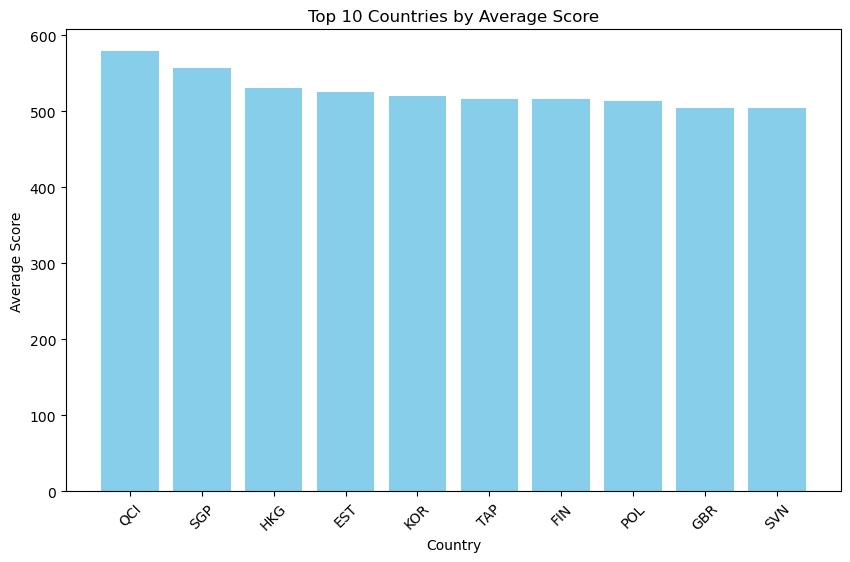

In [12]:
# Group by CNT and calculate the mean average score
grouped_data = Clean_Data.groupby('CNT').mean().reset_index()

# Sort the grouped data by average score in descending order and get the top 10
top_10_countries = grouped_data.sort_values(by='AverageScore', ascending=False).head(10)

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(top_10_countries['CNT'], top_10_countries['AverageScore'], color='skyblue')
plt.xlabel('Country')
plt.ylabel('Average Score')
plt.title('Top 10 Countries by Average Score')
plt.xticks(rotation=45)
plt.show()

In [13]:
# Assuming you have your DataFrame dfi_psi
columns_to_drop = ['M', 'BOOKID','CYC', 'ADMINMODE', 'SUBNATIO', 'NatCen', 'LANGTEST']  # Replace with actual column names

# Dropping the specified columns
df.drop(columns=columns_to_drop, inplace=True)

In [14]:
df[['CNTRYID','CNTSCHID', 'OECD','CREACTIV','CLSIZE','SCHSIZE','SC001Q01TA','TOTAT','SC002Q01TA','SC002Q02TA','SC052Q03HA','SCHLTYPE','SC052Q01NA', 'SC052Q02NA']] = df[['CNTRYID','CNTSCHID', 'OECD','CREACTIV','CLSIZE','SCHSIZE','SC001Q01TA','TOTAT','SC002Q01TA','SC002Q02TA','SC052Q03HA','SCHLTYPE','SC052Q01NA', 'SC052Q02NA' ]].apply(np.int64) 

In [15]:
#checking for duplicates
Clean_Data.duplicated().sum()

0

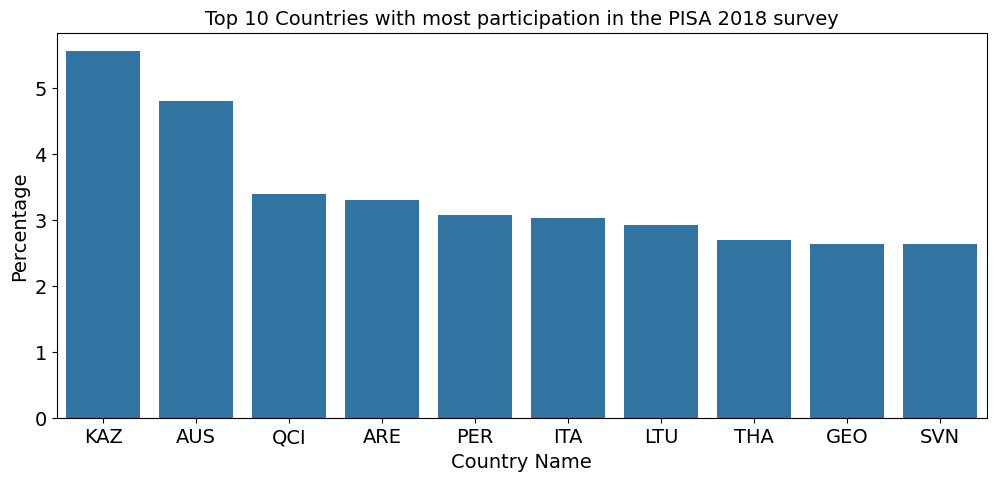

In [16]:
summary =Clean_Data.CNT.value_counts(normalize=True)*100
summary =summary.head(10)
summary_p = summary.dropna()


# Method that plots a bar chart given a summary of the data
def sumbar(summary_p,title,xlabel,ylabel):
    plt.figure(figsize=[12,5])
    ind=summary_p.index
    vl=summary_p.values
    sb.barplot(x=ind,y=vl,color=sb.color_palette()[0])
    plt.title(title,fontsize=14)
    plt.xlabel(xlabel,fontsize=14)
    plt.ylabel(ylabel,fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

# plotting bar given title and axis values
title='Top 10 Countries with most participation in the PISA 2018 survey'
sumbar(summary_p,title,'Country Name','Percentage')

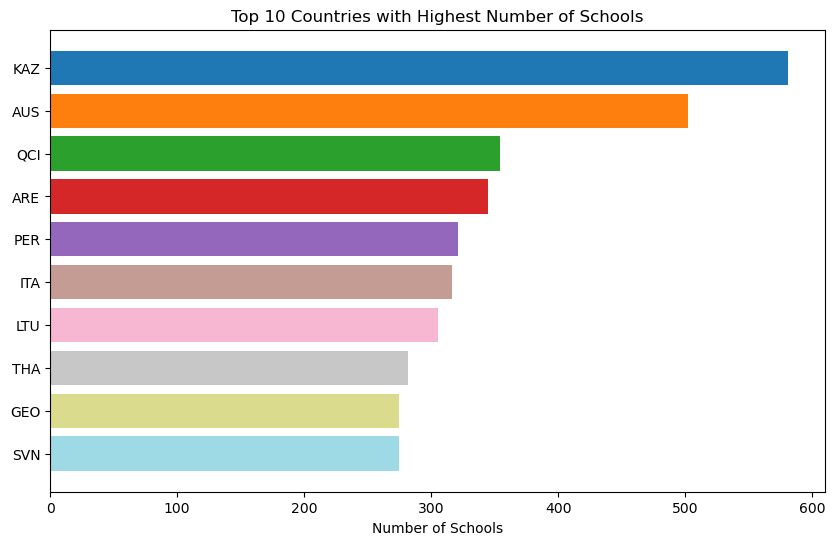

In [17]:
# Counting the number of unique schools for each country
school_counts = Clean_Data.groupby('CNT')['SchoolId'].nunique().reset_index()
school_counts = school_counts.rename(columns={'SchoolId': 'SchoolCount'})

# Sorting by SchoolCount and selecting the top 10 countries
top_10_countries = school_counts.sort_values(by='SchoolCount', ascending=False).head(10)

# Define a list of colors
colors = plt.cm.tab20(np.linspace(0, 1, len(top_10_countries)))

# Plotting the data
plt.figure(figsize=(10, 6))
plt.barh(top_10_countries['CNT'], top_10_countries['SchoolCount'], color=colors)
plt.xlabel('Number of Schools')
plt.title('Top 10 Countries with Highest Number of Schools')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest counts at the top
plt.show()

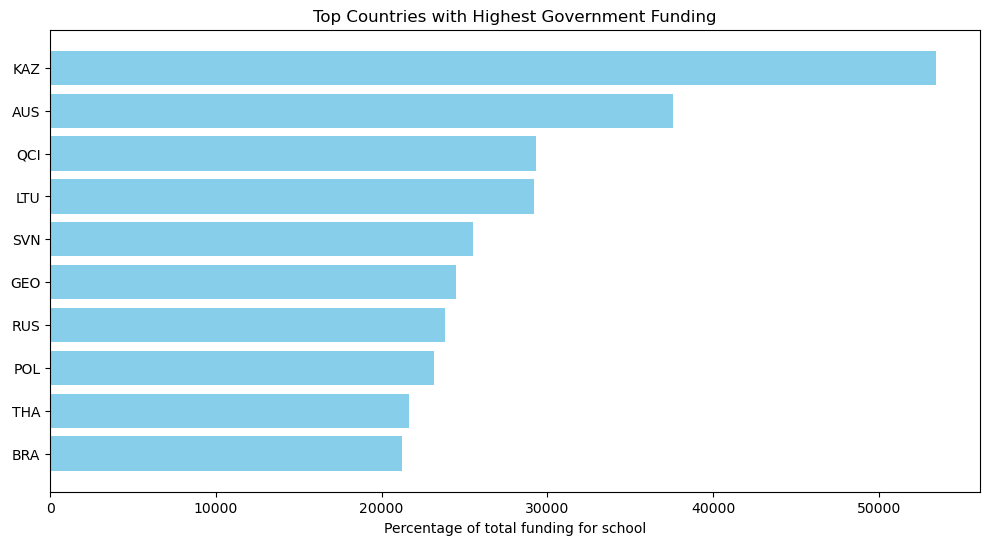

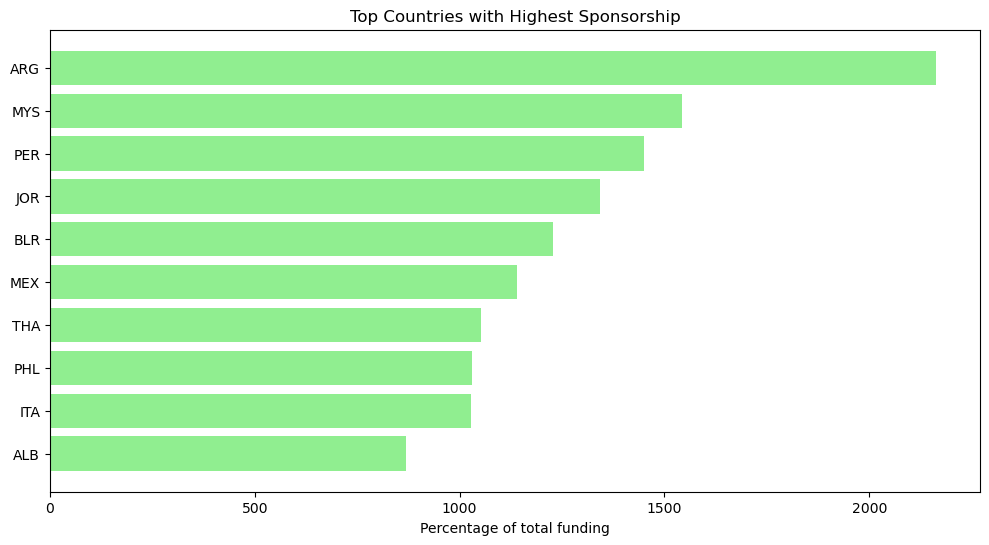

In [18]:
#Looking at the Impact of Govt Funding and Sponsorship for Students

# Aggregating GovtFunding and Sponsorship by country
funding_sponsorship = Clean_Data.groupby('CNT')[['GovtFunding', 'Sponsorship']].sum().reset_index()

# Plotting countries with highest GovtFunding
top_govt_funding = funding_sponsorship.sort_values(by='GovtFunding', ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.barh(top_govt_funding['CNT'], top_govt_funding['GovtFunding'], color='skyblue')
plt.xlabel('Percentage of total funding for school')
plt.title('Top Countries with Highest Government Funding')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest counts at the top
plt.show()

# Plotting countries with highest Sponsorship
top_sponsorship = funding_sponsorship.sort_values(by='Sponsorship', ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.barh(top_sponsorship['CNT'], top_sponsorship['Sponsorship'], color='lightgreen')
plt.xlabel('Percentage of total funding')
plt.title('Top Countries with Highest Sponsorship')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest counts at the top
plt.show()

In [19]:
##Looking at the Impact of School strategy

# Aggregating GovtFunding and Sponsorship by country
School_Strategies = Clean_Data.groupby('CNT')[['TeachersWithBSc', 'TeachersNotMeetingStudentNeeds',
                                                     'StudyRoomBySchool','ReceiveAdditionalPeriods',
                                                     'SkippingClasses']].sum().reset_index()

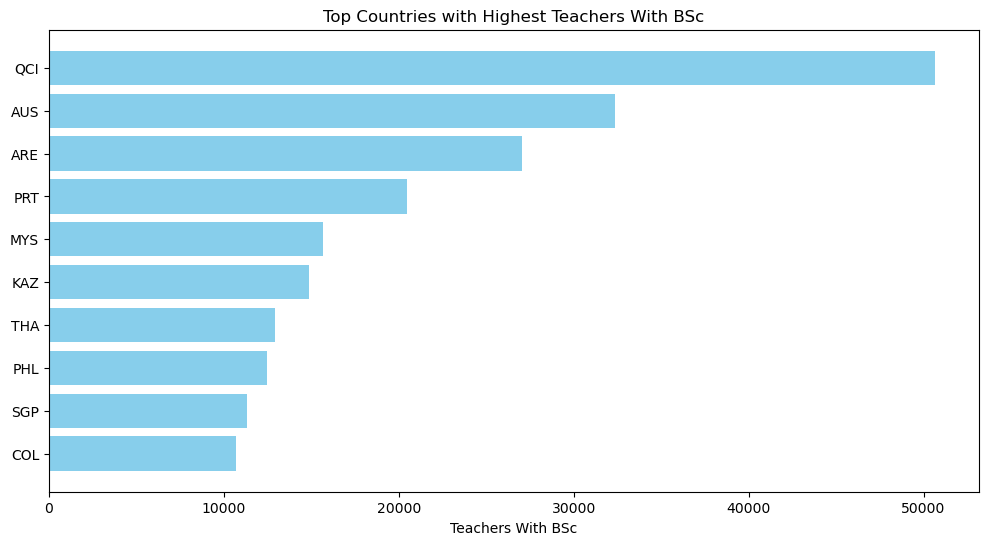

In [20]:

# Plotting countries with highest GovtFunding
top_BSc = School_Strategies.sort_values(by='TeachersWithBSc', ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.barh(top_BSc['CNT'], top_BSc['TeachersWithBSc'], color='skyblue')
plt.xlabel('Teachers With BSc')
plt.title('Top Countries with Highest Teachers With BSc')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest counts at the top
plt.show()

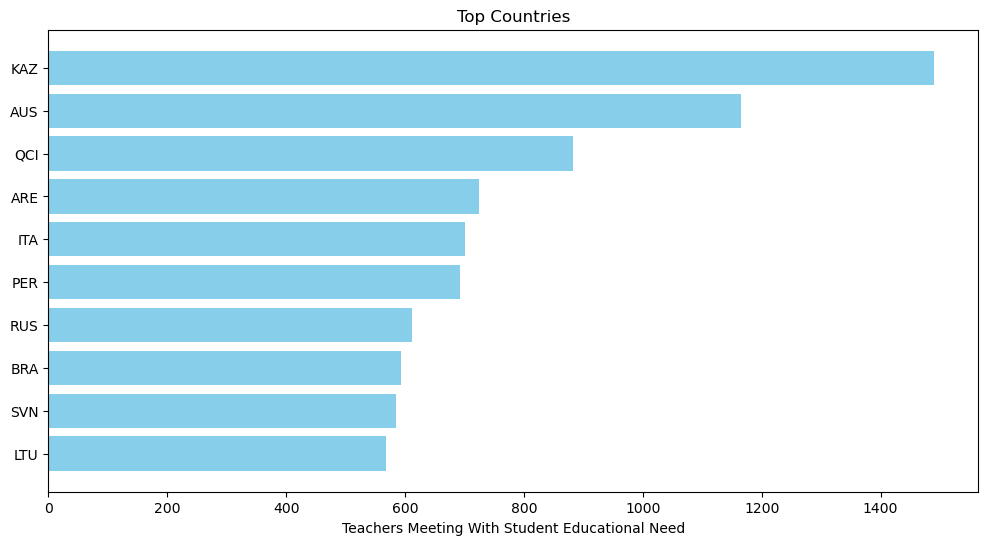

In [21]:
# Plotting countries with highest GovtFunding
MeetingStudentNeeds = School_Strategies.sort_values(by='TeachersNotMeetingStudentNeeds', ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.barh(MeetingStudentNeeds['CNT'], MeetingStudentNeeds['TeachersNotMeetingStudentNeeds'], color='skyblue')
plt.xlabel('Teachers Meeting With Student Educational Need')
plt.title('Top Countries')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest counts at the top
plt.show()

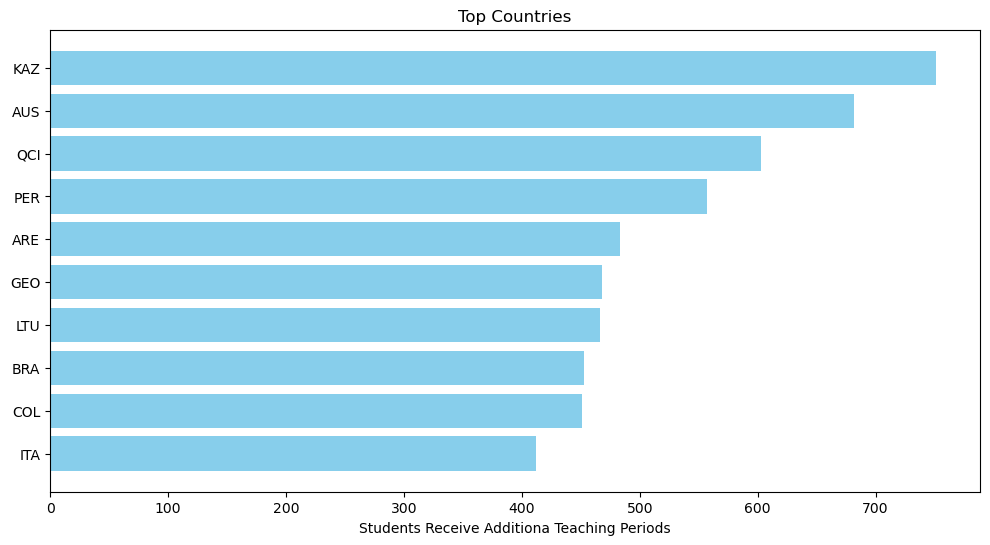

In [22]:
# Plotting countries with highest GovtFunding
ReceiveAdditionalPeriods = School_Strategies.sort_values(by='ReceiveAdditionalPeriods', ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.barh(ReceiveAdditionalPeriods['CNT'], ReceiveAdditionalPeriods['ReceiveAdditionalPeriods'], color='skyblue')
plt.xlabel('Students Receive Additiona Teaching Periods')
plt.title('Top Countries')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest counts at the top
plt.show()

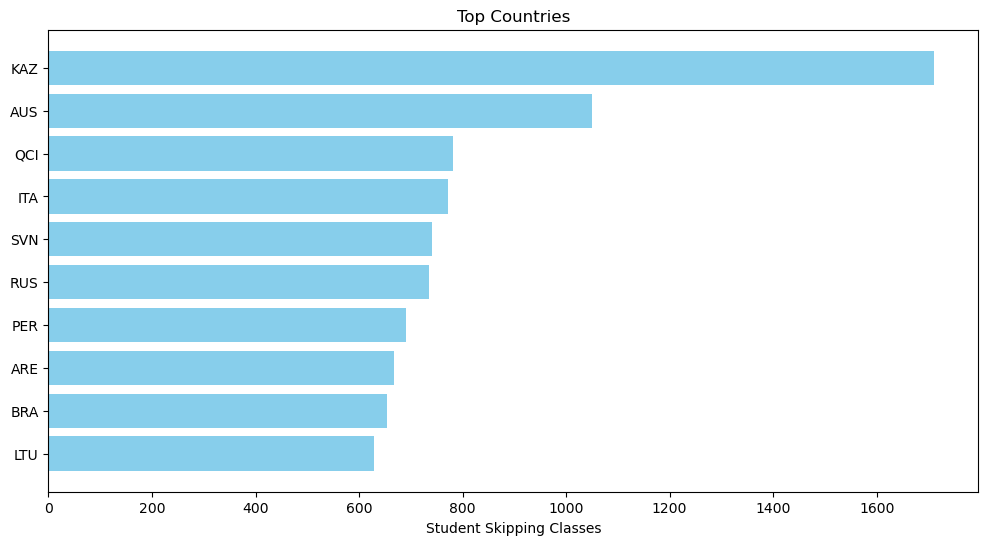

In [23]:
# Analyse School Strategies for Students
Student_Act = School_Strategies.sort_values(by='SkippingClasses', ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.barh(Student_Act['CNT'], Student_Act['SkippingClasses'], color='skyblue')
plt.xlabel('Student Skipping Classes')
plt.title('Top Countries')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest counts at the top
plt.show()

In [24]:
# Creating a new column 'Classification' based on the condition
Clean_Data['Classification'] = Clean_Data['AverageScore'].apply(lambda x: 'Good' if x >= 450 else 'Bad')
Clean_Data.Classification.value_counts()

Good    5423
Bad     5032
Name: Classification, dtype: int64

In [25]:
# Example variables related to teaching strategies
teaching_vars = ['TeachersWithBSc', 'TeachersNotMeetingStudentNeeds','StudyRoomBySchool','ReceiveAdditionalPeriods',
                'HostVisitingTeachers','EvaluateInstructionMaterial', 'GovtFunding', 'Sponsorship']
descriptive_stats = Clean_Data.groupby('CNT')[teaching_vars].describe()
descriptive_stats

TeachersWithBSc                                                       \
              count       mean        std  min   25%   50%    75%    max   
CNT                                                                        
ALB            91.0   2.043956   5.765630  0.0   0.0   0.0   2.00   50.0   
ARE           345.0  78.313043  59.782654  8.0  37.0  58.0  98.00  340.0   
ARG           192.0  29.854167  53.422739  0.0   3.0  14.0  30.00  380.0   
AUS           502.0  64.434263  34.264013  0.0  40.0  60.0  81.00  210.0   
BGR           109.0   8.431193  10.358721  0.0   2.0   5.0  10.00   68.0   
..              ...        ...        ...  ...   ...   ...    ...    ...   
TAP           143.0  45.405594  36.013737  0.0  20.0  35.0  57.50  230.0   
THA           282.0  45.765957  43.920851  0.0  15.0  30.0  64.75  368.0   
TUR            91.0  50.736264  29.708149  0.0  33.0  44.0  60.00  183.0   
URY           185.0   1.432432   3.728129  0.0   0.0   0.0   1.00   35.0   
USA            85.0  62.141176  44.102465  1.0  30.0  55.0  90.00  225.0   

    TeachersNotMeetingStudentNeeds            ... GovtFunding         \
                             count      mean  ...         75%    max   
CNT                                           ...                      
ALB                           91.0  1.318681  ...       100.0  100.0   
ARE                          345.0  2.098551  ...       100.0  100.0   
ARG                          192.0  2.260417  ...        90.0  100.0   
AUS                          502.0  2.320717  ...        95.0  100.0   
BGR                          109.0  1.917431  ...       100.0  100.0   
..                             ...       ...  ...         ...    ...   
TAP                          143.0  2.209790  ...        95.0  100.0   
THA                          282.0  1.641844  ...       100.0  100.0   
TUR                           91.0  2.153846  ...        95.0  100.0   
URY                          185.0  2.351351  ...       100.0  100.0   
USA                           85.0  2.305882  ...       100.0  100.0   

    Sponsorship                                                    
          count       mean        std  min  25%  50%   75%    max  
CNT                                                                
ALB        91.0   9.538462  21.860826  0.0  0.0  0.0   5.0  100.0  
ARE       345.0   1.721739   7.969288  0.0  0.0  0.0   0.0  100.0  
ARG       192.0  11.260417  21.749042  0.0  0.0  0.0  10.0  100.0  
AUS       502.0   1.227092   3.259291  0.0  0.0  0.0   1.0   50.0  
BGR       109.0   0.990826   3.640043  0.0  0.0  0.0   0.0   25.0  
..          ...        ...        ...  ...  ...  ...   ...    ...  
TAP       143.0   2.545455   6.279552  0.0  0.0  1.0   2.0   60.0  
THA       282.0   3.734043   6.470039  0.0  0.0  0.5   5.0   35.0  
TUR        91.0   9.098901  13.130165  0.0  0.0  5.0  10.0   70.0  
URY       185.0   3.610811   8.927236  0.0  0.0  0.0   2.0   80.0  
USA        85.0   2.611765   4.933110  0.0  0.0  0.0   3.0   20.0  

[64 rows x 64 columns]

In [26]:
# Example t-test between high-performing and other countries
from scipy.stats import ttest_ind
high_perf_data = Clean_Data[Clean_Data['CNT'].isin(top_10_countries['CNT'])]
other_data = Clean_Data[~Datacleaned['CNT'].isin(top_10_countries['CNT'])]

for var in teaching_vars:
    t_stat, p_val = ttest_ind(high_perf_data[var], other_data[var], nan_policy='omit')
    print(f"T-test for {var}: t_stat={t_stat}, p_val={p_val}")

T-test for TeachersWithBSc: t_stat=18.408611733334837, p_val=1.674916408725162e-74
T-test for TeachersNotMeetingStudentNeeds: t_stat=5.080625983492684, p_val=3.82690700479302e-07
T-test for StudyRoomBySchool: t_stat=-2.036608379950301, p_val=0.04171445085053929
T-test for ReceiveAdditionalPeriods: t_stat=-12.56522629129605, p_val=5.961769412900114e-36
T-test for HostVisitingTeachers: t_stat=-11.012436685201662, p_val=4.74646249195352e-28
T-test for EvaluateInstructionMaterial: t_stat=-7.913997222172714, p_val=2.744809295608187e-15
T-test for GovtFunding: t_stat=-12.275250643164183, p_val=2.121438176096451e-34
T-test for Sponsorship: t_stat=-6.00449848885729, p_val=1.9830777124881854e-09


In [27]:
# Correlation analysis
correlations = high_perf_data[teaching_vars].corr()
correlations

,TeachersWithBSc,TeachersNotMeetingStudentNeeds,StudyRoomBySchool,ReceiveAdditionalPeriods,HostVisitingTeachers,EvaluateInstructionMaterial,GovtFunding,Sponsorship
TeachersWithBSc,1.000000,0.084375,0.039787,-0.006828,-0.257747,-0.176996,-0.139454,-0.036135
TeachersNotMeetingStudentNeeds,0.084375,1.000000,0.070327,-0.012610,-0.045400,-0.024644,0.081761,0.003549
StudyRoomBySchool,0.039787,0.070327,1.000000,0.126899,0.108710,-0.014016,-0.005048,-0.016284
ReceiveAdditionalPeriods,-0.006828,-0.012610,0.126899,1.000000,0.167670,0.061406,0.015675,-0.004218
HostVisitingTeachers,-0.257747,-0.045400,0.108710,0.167670,1.000000,0.123344,-0.051896,0.051779
EvaluateInstructionMaterial,-0.176996,-0.024644,-0.014016,0.061406,0.123344,1.000000,0.087651,-0.009854
GovtFunding,-0.139454,0.081761,-0.005048,0.015675,-0.051896,0.087651,1.000000,-0.204467
Sponsorship,-0.036135,0.003549,-0.016284,-0.004218,0.051779,-0.009854,-0.204467,1.000000


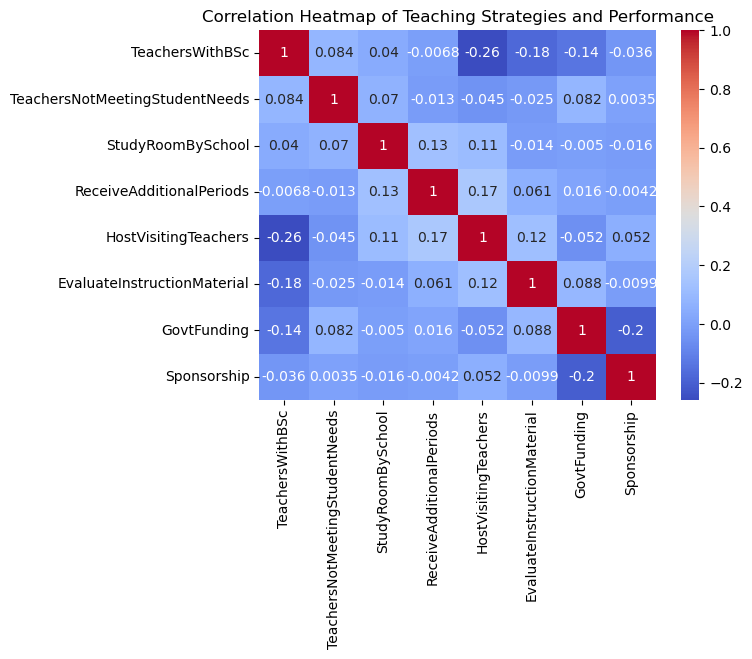

In [28]:
# Heatmap
sb.heatmap(correlations, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Teaching Strategies and Performance')
plt.show()

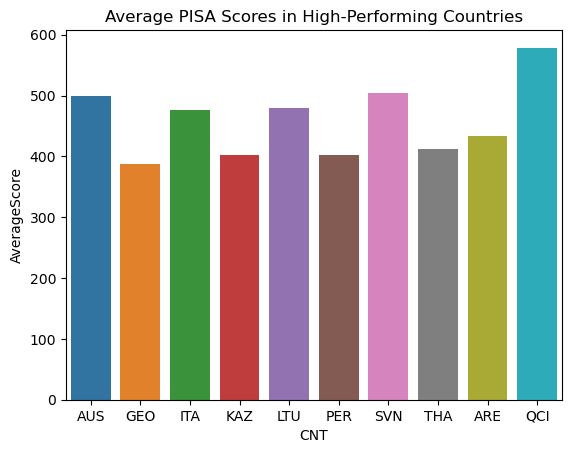

In [29]:
# Bar Plot
sb.barplot(data=high_perf_data, x='CNT', y='AverageScore')
plt.title('Average PISA Scores in High-Performing Countries')
plt.show()

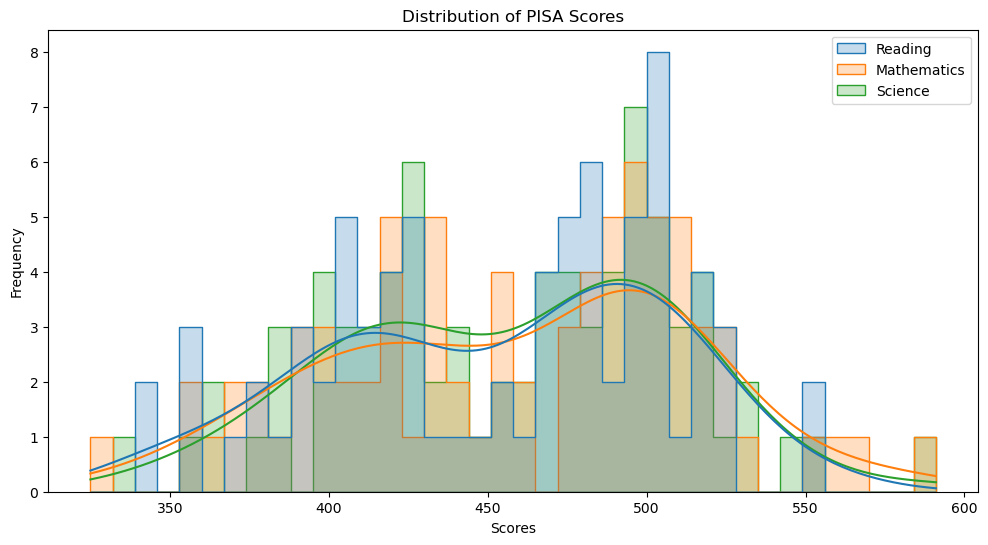

In [30]:
# Dropping the 'AverageScore' column
scores_df = df_scores.drop(columns=['AverageScore'])

# Plotting the distribution of the scores
plt.figure(figsize=(12, 6))

# Creating a boxplot for each subject
sb.histplot(data = scores_df, bins = 15, element = 'step', binwidth = 7, kde = True)
plt.title('Distribution of PISA Scores')
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.show()

In [31]:
Clean_Data

,CNT,SchoolId,CountryStatus,ModeofRespondent,LocationOfSchool,GovtFunding,Sponsorship,InAdequateStaff,InAdequateMaterial,InAdequateMaterial,...,SCHSIZE,TeachersTotal,CLSIZE,ExtraActivitiesOffered,Countrys,Reading,Mathematics,Science,AverageScore,Classification
2,ALB,800004.0,0.0,2.0,1.0,100.0,0.0,1.0,2.0,2.0,...,205.0,21.0,18.0,1.0,Albania,405.0,437.0,417.0,419.67,Bad
5,ALB,800007.0,0.0,2.0,1.0,100.0,0.0,1.0,3.0,2.0,...,45.0,9.5,13.0,1.0,Albania,405.0,437.0,417.0,419.67,Bad
7,ALB,800009.0,0.0,2.0,4.0,0.0,100.0,2.0,2.0,2.0,...,823.0,48.5,28.0,1.0,Albania,405.0,437.0,417.0,419.67,Bad
14,ALB,800016.0,0.0,2.0,1.0,70.0,10.0,2.0,3.0,4.0,...,47.0,7.0,13.0,1.0,Albania,405.0,437.0,417.0,419.67,Bad
15,ALB,800017.0,0.0,2.0,4.0,0.0,0.0,1.0,1.0,1.0,...,100.0,12.5,18.0,1.0,Albania,405.0,437.0,417.0,419.67,Bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21597,QCI,97500357.0,0.0,2.0,4.0,99.0,0.0,3.0,1.0,2.0,...,3067.0,374.0,43.0,1.0,B-S-J-Z (China),555.0,591.0,590.0,578.67,Good
21599,QCI,97500359.0,0.0,2.0,3.0,90.0,0.0,1.0,1.0,1.0,...,2298.0,203.0,43.0,1.0,B-S-J-Z (China),555.0,591.0,590.0,578.67,Good
21600,QCI,97500360.0,0.0,2.0,4.0,87.0,0.0,2.0,1.0,1.0,...,2605.0,266.0,48.0,1.0,B-S-J-Z (China),555.0,591.0,590.0,578.67,Good
21601,QCI,97500361.0,0.0,2.0,2.0,100.0,0.0,3.0,2.0,2.0,...,2005.0,170.0,38.0,1.0,B-S-J-Z (China),555.0,591.0,590.0,578.67,Good


In [32]:
# method to plot correlation between two variable while computing their Correlatio coefficient along
def corrp(x,y,xlabel,ylabel):
    ccoefficient=Clean_Data[x].corr(Clean_Data[y])
    print('Correlation coefficient',ccoefficient.round(2))
    sb.regplot(data = Clean_Data, x = x, y = y, x_jitter=0.04, scatter_kws={'alpha':1/10}, fit_reg=False)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title('Correlation between ' + xlabel + ' and ' + ylabel);
    

def corp(x, y_list, xlabel, ylabel_list):
    for y, ylabel in zip(y_list, ylabel_list):
        ccoefficient = Clean_Data[x].corr(Clean_Data[y])
        print(f'Correlation coefficient between {xlabel} and {ylabel}:', ccoefficient.round(2))
        

# passing plot parameters and plotting chart
x = 'AverageScore'
y = ['GovtFunding', 'Sponsorship', 'TeachersWithBSc', 'ReceiveAdditionalPeriods', 'ExtraActivitiesOffered', 'SkippingClasses']
xlabel = 'AverageScore'
ylabel_list = ['GovtFunding', 'Sponsorship', 'TeachersWithBSc', 'ReceiveAdditionalPeriods', 'ExtraActivitiesOffered', 'SkippingClasses']
corp(x,y,x,y)




Correlation coefficient between AverageScore and GovtFunding: 0.15
Correlation coefficient between AverageScore and Sponsorship: -0.13
Correlation coefficient between AverageScore and TeachersWithBSc: 0.19
Correlation coefficient between AverageScore and ReceiveAdditionalPeriods: -0.13
Correlation coefficient between AverageScore and ExtraActivitiesOffered: -0.1
Correlation coefficient between AverageScore and SkippingClasses: -0.06


In [33]:
#'DigitalDevices', 'TeachersWithBSc', 'Classification','StudyRoomBySchool', 'CLSIZE','ExtraActivitiesOffered'

<Figure size 1000x600 with 0 Axes>

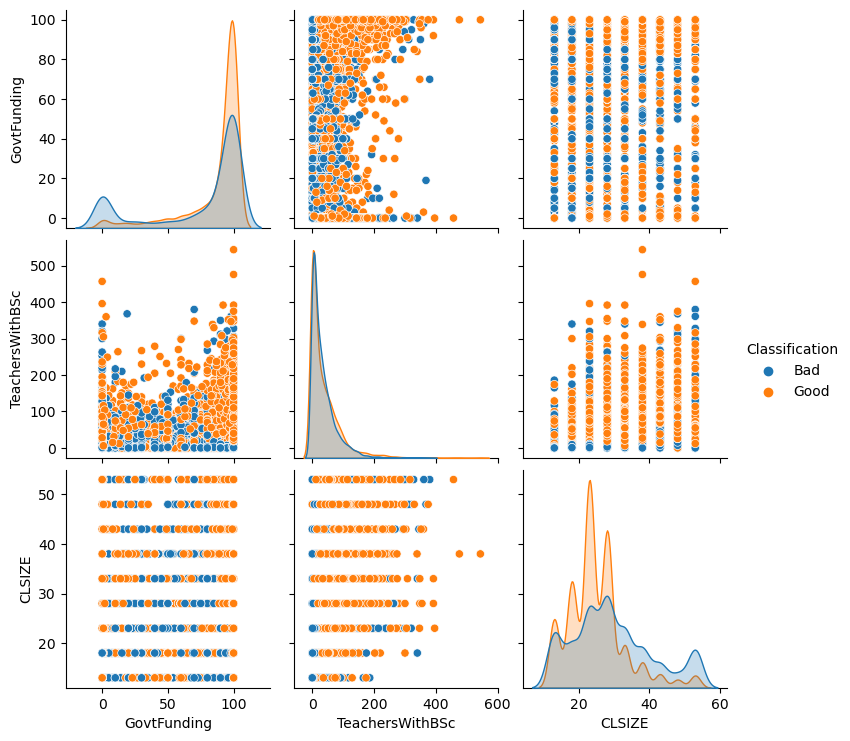

In [34]:
y = ['GovtFunding', 'TeachersWithBSc','CLSIZE','Classification']

Pair_Data = Clean_Data[y]

# Plot pairplot
plt.figure(figsize=(10, 6))
sb.pairplot(Pair_Data, hue='Classification', diag_kind='kde')
plt.show()

In [35]:
Clean_Data

,CNT,SchoolId,CountryStatus,ModeofRespondent,LocationOfSchool,GovtFunding,Sponsorship,InAdequateStaff,InAdequateMaterial,InAdequateMaterial,...,SCHSIZE,TeachersTotal,CLSIZE,ExtraActivitiesOffered,Countrys,Reading,Mathematics,Science,AverageScore,Classification
2,ALB,800004.0,0.0,2.0,1.0,100.0,0.0,1.0,2.0,2.0,...,205.0,21.0,18.0,1.0,Albania,405.0,437.0,417.0,419.67,Bad
5,ALB,800007.0,0.0,2.0,1.0,100.0,0.0,1.0,3.0,2.0,...,45.0,9.5,13.0,1.0,Albania,405.0,437.0,417.0,419.67,Bad
7,ALB,800009.0,0.0,2.0,4.0,0.0,100.0,2.0,2.0,2.0,...,823.0,48.5,28.0,1.0,Albania,405.0,437.0,417.0,419.67,Bad
14,ALB,800016.0,0.0,2.0,1.0,70.0,10.0,2.0,3.0,4.0,...,47.0,7.0,13.0,1.0,Albania,405.0,437.0,417.0,419.67,Bad
15,ALB,800017.0,0.0,2.0,4.0,0.0,0.0,1.0,1.0,1.0,...,100.0,12.5,18.0,1.0,Albania,405.0,437.0,417.0,419.67,Bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21597,QCI,97500357.0,0.0,2.0,4.0,99.0,0.0,3.0,1.0,2.0,...,3067.0,374.0,43.0,1.0,B-S-J-Z (China),555.0,591.0,590.0,578.67,Good
21599,QCI,97500359.0,0.0,2.0,3.0,90.0,0.0,1.0,1.0,1.0,...,2298.0,203.0,43.0,1.0,B-S-J-Z (China),555.0,591.0,590.0,578.67,Good
21600,QCI,97500360.0,0.0,2.0,4.0,87.0,0.0,2.0,1.0,1.0,...,2605.0,266.0,48.0,1.0,B-S-J-Z (China),555.0,591.0,590.0,578.67,Good
21601,QCI,97500361.0,0.0,2.0,2.0,100.0,0.0,3.0,2.0,2.0,...,2005.0,170.0,38.0,1.0,B-S-J-Z (China),555.0,591.0,590.0,578.67,Good


In [36]:
Xx = Clean_Data[['GovtFunding', 'TeachersWithBSc', 'LocationOfSchool', 'DigitalDevices', 
  'StudyRoomBySchool', 'CLSIZE','ExtraActivitiesOffered']]
#Xx = Clean_Data[['GovtFunding', 'TeachersWithBSc', 'LocationOfSchool', 'DigitalDevices', 
 #                'StudyRoomBySchool',
 #           'CLSIZE','ExtraActivitiesOffered']]
Xx = pd.get_dummies(data = Xx, drop_first = True)
# Removing rows with any 0.0 values
Xx = Xx[(Xx.T != 0.0).all()]
Xx = Xx.head(1000)
Xx

,GovtFunding,TeachersWithBSc,LocationOfSchool,DigitalDevices,StudyRoomBySchool,CLSIZE,ExtraActivitiesOffered
2,100.0,11.0,1.0,2.0,1.0,18.0,1.0
16,18.0,5.0,4.0,1.0,2.0,23.0,1.0
29,100.0,2.0,4.0,3.0,2.0,48.0,2.0
34,94.0,1.0,3.0,2.0,2.0,28.0,1.0
48,85.0,2.0,1.0,2.0,2.0,23.0,1.0
...,...,...,...,...,...,...,...
3136,100.0,68.0,1.0,3.0,1.0,23.0,2.0
3137,25.0,59.0,2.0,2.0,1.0,28.0,1.0
3138,27.0,58.0,3.0,2.0,2.0,23.0,2.0
3139,90.0,54.0,2.0,4.0,2.0,28.0,2.0


In [37]:
Yy = Clean_Data[['Classification']].head(1000)

In [38]:
# Split the dataset into training and testing sets
NX_train, NX_test, Ny_train, Ny_test = train_test_split(Xx, Yy, test_size=0.30, random_state=42) 

In [39]:

# Define the parameter grid
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Initialize the Random Forest classifier
Nrf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV with 5-fold cross-validation
Ngrid_search = GridSearchCV(estimator=Nrf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

try:
    # Fit the model
    Ngrid_search.fit(NX_train, Ny_train)
    
    # Get the best parameters and best score
    Nbest_params = Ngrid_search.best_params_
    Nbest_score = Ngrid_search.best_score_

    # Predict on the test set
    New_y_pred = Ngrid_search.predict(NX_test)
    


    # Calculate the test accuracy
    New_test_accuracy = accuracy_score(Ny_test, New_y_pred)

    # Display the results
    print("Best Parameters:", Nbest_params)
    print("Best Cross-Validation Score:", Nbest_score)
    print("Test Set Accuracy:", New_test_accuracy)
    
    # Generate classification report with string labels
    Nreport = classification_report(Ny_test, New_y_pred)
         
    print(Nreport)
except TypeError as e:
    print(f"TypeError encountered: {e}")
except ValueError as e:
    print(f"ValueError encountered: {e}")
except Exception as e:
    print(f"An error occurred: {e}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-Validation Score: 0.8171428571428573
Test Set Accuracy: 0.7533333333333333
              precision    recall  f1-score   support

         Bad       0.87      0.63      0.73       160
        Good       0.68      0.89      0.77       140

    accuracy                           0.75       300
   macro avg       0.78      0.76      0.75       300
weighted avg       0.78      0.75      0.75       300



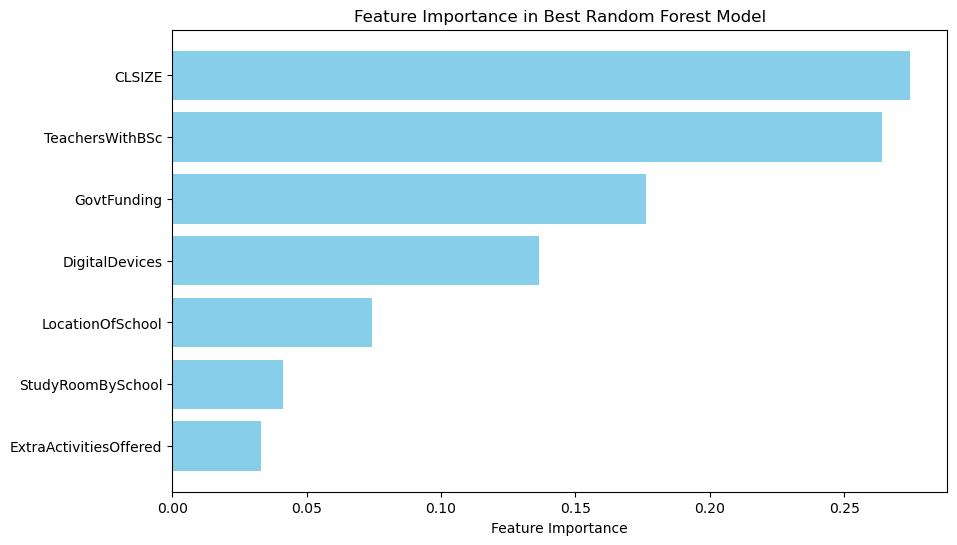

In [40]:
# Extract feature importance from the best model
best_rf_model = Ngrid_search.best_estimator_
feature_importances = best_rf_model.feature_importances_

# Plotting the feature importances
feature_names = NX_train.columns
sorted_idx = np.argsort(feature_importances)

plt.figure(figsize=(10, 6))
plt.barh(feature_names[sorted_idx], feature_importances[sorted_idx], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Best Random Forest Model')
plt.show()

In [153]:
from sklearn.neighbors import KNeighborsClassifier


# Define a parameter grid for KNN
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'knn__p': [1, 2]  # Parameter for the Minkowski metric, where p=1 is equivalent to the Manhattan distance and p=2 to the Euclidean distance
}
# Create a pipeline with scaling and KNN
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Initialize GridSearchCV with 5-fold cross-validation
Kngrid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

try:
    # Fit the model
    Kngrid_search.fit(NX_train, Ny_train)
    
    # Get the best parameters and best score
    best_params = Kngrid_search.best_params_
    best_score = Kngrid_search.best_score_

    # Predict on the test set
    K_y_pred = Kngrid_search.predict(NX_test)

    # Calculate the test accuracy
    K_test_accuracy = accuracy_score(Ny_test, K_y_pred)

    # Generate the classification report
    report = classification_report(Ny_test, K_y_pred)

    # Display the results
    print("Best Parameters:", best_params)
    print("Best Cross-Validation Score:", best_score)
    print("Test Set Accuracy:", K_test_accuracy)
    print("\nClassification Report:\n", report)
except TypeError as e:
    print(f"TypeError encountered: {e}")
except ValueError as e:
    print(f"ValueError encountered: {e}")
except Exception as e:
    print(f"An error occurred: {e}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters: {'knn__algorithm': 'auto', 'knn__n_neighbors': 9, 'knn__p': 2, 'knn__weights': 'uniform'}
Best Cross-Validation Score: 0.75
Test Set Accuracy: 0.73

Classification Report:
               precision    recall  f1-score   support

         Bad       0.92      0.54      0.68       160
        Good       0.64      0.95      0.77       140

    accuracy                           0.73       300
   macro avg       0.78      0.74      0.72       300
weighted avg       0.79      0.73      0.72       300



In [154]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Define the parameter grid with more parameters for Decision Tree
param_grid = {
    'dt__criterion': ['gini', 'entropy'],
    'dt__max_depth': [None, 10, 20],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 4]
}

# Initialize the Decision Tree classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

try:
    # Fit the model
    grid_search.fit(NX_train, Ny_train)
    
    # Get the best parameters and best score
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    # Predict on the test set
    D_y_pred = grid_search.predict(NX_test)

    # Calculate the test accuracy
    test_accuracy = accuracy_score(Ny_test, D_y_pred)

   

    # Generate the classification report
    report = classification_report(Ny_test, D_y_pred)

    # Display the results
    print("Best Parameters:", best_params)
    print("Best Cross-Validation Score:", best_score)
    print("Test Set Accuracy:", test_accuracy)
    print("\nClassification Report:\n", report)
except TypeError as e:
    print(f"TypeError encountered: {e}")
except ValueError as e:
    print(f"ValueError encountered: {e}")
except Exception as e:
    print(f"An error occurred: {e}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'dt__criterion': 'gini', 'dt__max_depth': 10, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 10}
Best Cross-Validation Score: 0.76
Test Set Accuracy: 0.71

Classification Report:
               precision    recall  f1-score   support

         Bad       0.75      0.69      0.72       160
        Good       0.67      0.74      0.70       140

    accuracy                           0.71       300
   macro avg       0.71      0.71      0.71       300
weighted avg       0.71      0.71      0.71       300



In [ ]:
# Split the dataset into training and testing sets
NX_train, NX_test, Ny_train, Ny_test = train_test_split(X, Y, test_size=0.30, random_state=42) 

In [33]:
X = Clean_Data[['GovtFunding', 'TeachersWithBSc']]
X = pd.get_dummies(data = X, drop_first = True)
# Removing rows with any 0.0 values
X = X[(X.T != 0.0).all()]
X = X.head(1000)
X

,GovtFunding,TeachersWithBSc
2,100.0,11.0
16,18.0,5.0
29,100.0,2.0
34,94.0,1.0
48,85.0,2.0
...,...,...
3136,100.0,68.0
3137,25.0,59.0
3138,27.0,58.0
3139,90.0,54.0


In [34]:
# Split the dataset into training and testing sets
NX_train, NX_test, Ny_train, Ny_test = train_test_split(X, Y, test_size=0.30, random_state=42) 

In [51]:

# Define the parameter grid
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Initialize the Random Forest classifier
Nrf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV with 5-fold cross-validation
Ngrid_search = GridSearchCV(estimator=Nrf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

try:
    # Fit the model
    Ngrid_search.fit(NX_train, Ny_train)
    
    # Get the best parameters and best score
    Nbest_params = Ngrid_search.best_params_
    Nbest_score = Ngrid_search.best_score_

    # Predict on the test set
    New_y_pred = Ngrid_search.predict(NX_test)
    


    # Calculate the test accuracy
    New_test_accuracy = accuracy_score(Ny_test, New_y_pred)

    # Display the results
    print("Best Parameters:", Nbest_params)
    print("Best Cross-Validation Score:", Nbest_score)
    print("Test Set Accuracy:", New_test_accuracy)
    
    # Generate classification report with string labels
    Nreport = classification_report(Ny_test, New_y_pred)
         
    print(Nreport)
except TypeError as e:
    print(f"TypeError encountered: {e}")
except ValueError as e:
    print(f"ValueError encountered: {e}")
except Exception as e:
    print(f"An error occurred: {e}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Best Cross-Validation Score: 0.7257142857142858
Test Set Accuracy: 0.6433333333333333
              precision    recall  f1-score   support

         Bad       0.69      0.61      0.64       160
        Good       0.60      0.69      0.64       140

    accuracy                           0.64       300
   macro avg       0.65      0.65      0.64       300
weighted avg       0.65      0.64      0.64       300



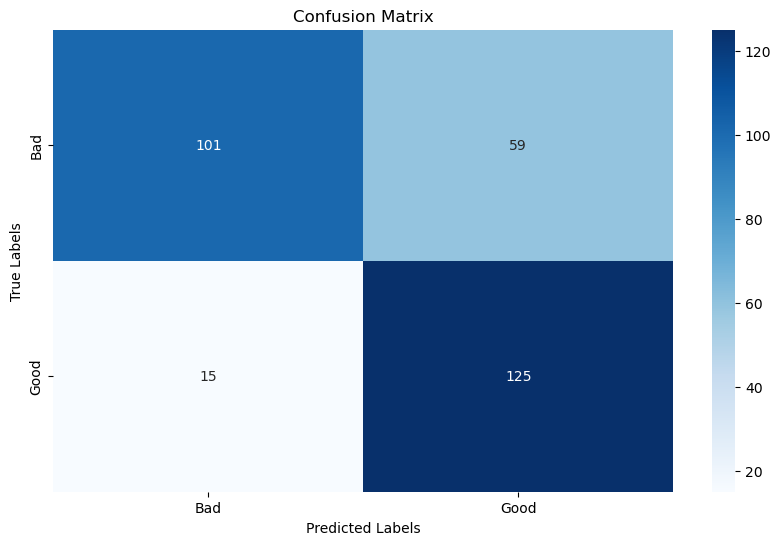

In [159]:
# Create a confusion matrix
conf_matrix = confusion_matrix(Ny_test, New_y_pred)
    
# Plot confusion matrix
plt.figure(figsize=(10, 6))
sb.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=Ngrid_search.classes_, yticklabels=Ngrid_search.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

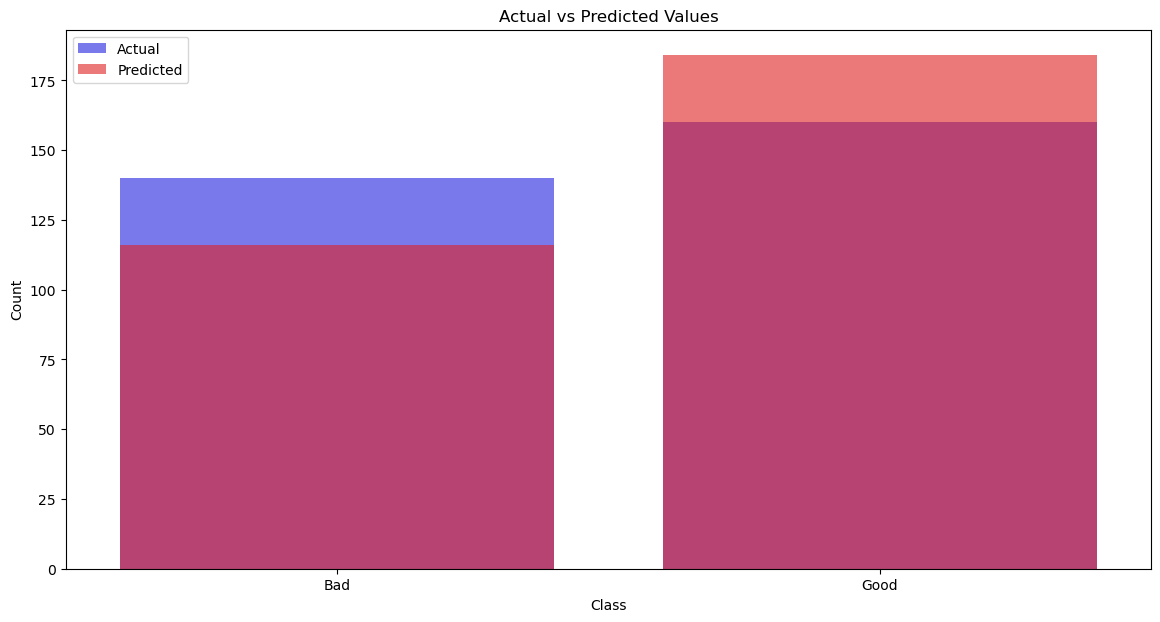

In [160]:
# Create a DataFrame with actual and predicted values
# Ensure Ny_test is a 1-dimensional array
Ny_test_array = Ny_test.to_numpy().flatten() if hasattr(Ny_test, 'to_numpy') else Ny_test.flatten()
New_y_pred_array = New_y_pred.flatten()

# Create a DataFrame with actual and predicted values
results_df = pd.DataFrame({'Actual': Ny_test_array, 'Predicted': New_y_pred_array})
    
    
# Plot actual and predicted values
plt.figure(figsize=(14, 7))
sb.countplot(x='Actual', data=results_df, color='blue', alpha=0.6, label='Actual')
sb.countplot(x='Predicted', data=results_df, color='red', alpha=0.6, label='Predicted')
plt.title('Actual vs Predicted Values')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend()
plt.show()

In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Define the parameter grid with more parameters for Decision Tree
param_grid = {
    'dt__criterion': ['gini', 'entropy'],
    'dt__max_depth': [None, 10, 20],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 4]
}

# Initialize the Decision Tree classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

try:
    # Fit the model
    grid_search.fit(NX_train, Ny_train)
    
    # Get the best parameters and best score
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    # Predict on the test set
    D_y_pred = grid_search.predict(NX_test)

    # Calculate the test accuracy
    test_accuracy = accuracy_score(Ny_test, D_y_pred)

   

    # Generate the classification report
    report = classification_report(Ny_test, D_y_pred)

    # Display the results
    print("Best Parameters:", best_params)
    print("Best Cross-Validation Score:", best_score)
    print("Test Set Accuracy:", test_accuracy)
    print("\nClassification Report:\n", report)
except TypeError as e:
    print(f"TypeError encountered: {e}")
except ValueError as e:
    print(f"ValueError encountered: {e}")
except Exception as e:
    print(f"An error occurred: {e}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'dt__criterion': 'entropy', 'dt__max_depth': 10, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 5}
Best Cross-Validation Score: 0.6871428571428572
Test Set Accuracy: 0.63

Classification Report:
               precision    recall  f1-score   support

         Bad       0.68      0.58      0.63       160
        Good       0.59      0.69      0.63       140

    accuracy                           0.63       300
   macro avg       0.63      0.63      0.63       300
weighted avg       0.64      0.63      0.63       300



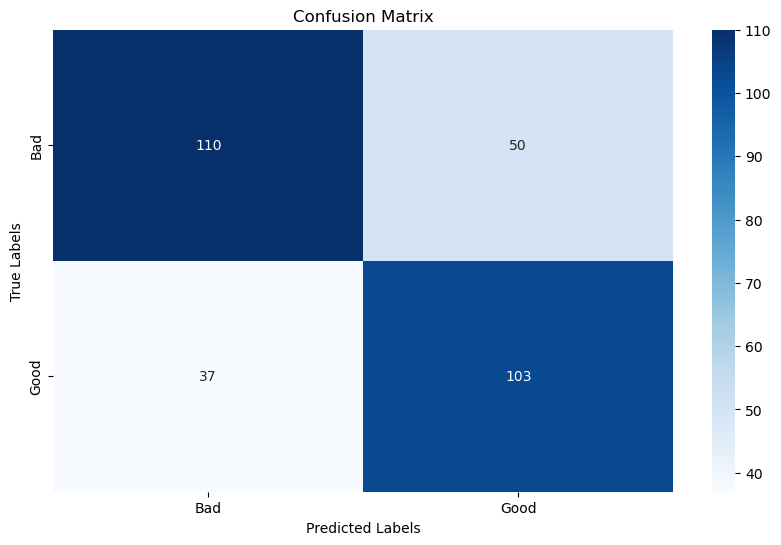

In [157]:
# Create a confusion matrix
Decconf_matrix = confusion_matrix(Ny_test, D_y_pred)
    
# Plot confusion matrix
plt.figure(figsize=(10, 6))
sb.heatmap(Decconf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=grid_search.classes_, yticklabels=grid_search.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

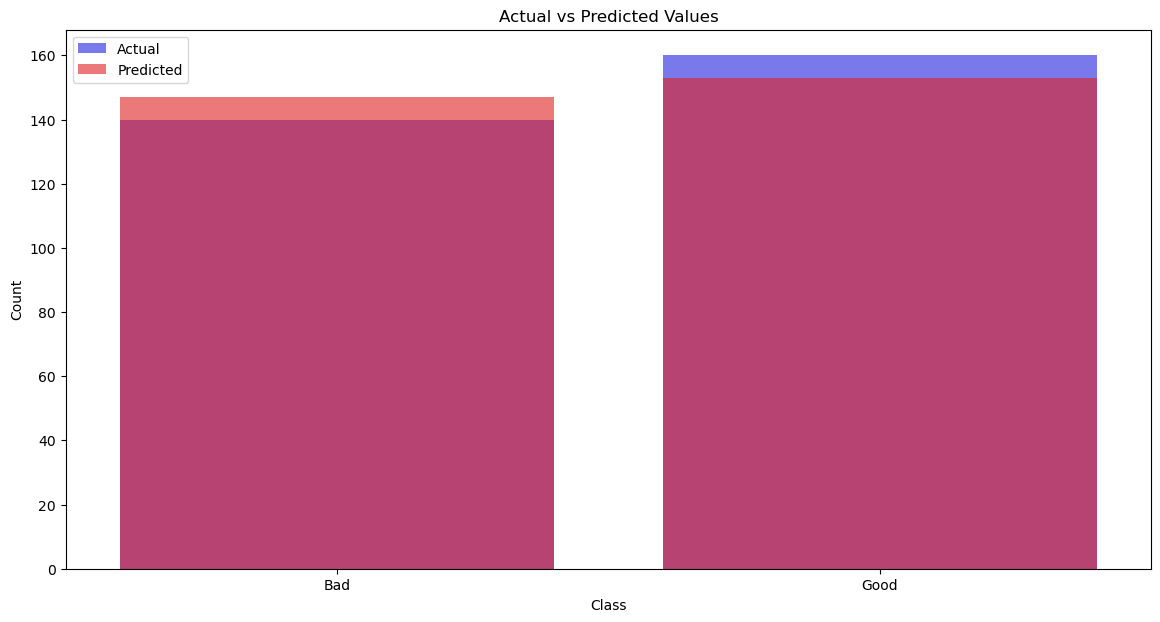

In [158]:
# Ensure Ny_test is a 1-dimensional array
D_y_pred_array = D_y_pred.flatten()

# Create a DataFrame with actual and predicted values
Decresults_df = pd.DataFrame({'Actual': Ny_test_array, 'Predicted': D_y_pred_array})
    
    
# Plot actual and predicted values
plt.figure(figsize=(14, 7))
sb.countplot(x='Actual', data=Decresults_df, color='blue', alpha=0.6, label='Actual')
sb.countplot(x='Predicted', data=Decresults_df, color='red', alpha=0.6, label='Predicted')
plt.title('Actual vs Predicted Values')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend()
plt.show()

In [61]:
from sklearn.neighbors import KNeighborsClassifier


# Define a parameter grid for KNN
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'knn__p': [1, 2]  # Parameter for the Minkowski metric, where p=1 is equivalent to the Manhattan distance and p=2 to the Euclidean distance
}


# Create a pipeline with scaling and KNN
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Initialize GridSearchCV with 5-fold cross-validation
Kngrid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

try:
    # Fit the model
    Kngrid_search.fit(NX_train, Ny_train)
    
    # Get the best parameters and best score
    best_params = Kngrid_search.best_params_
    best_score = Kngrid_search.best_score_

    # Predict on the test set
    K_y_pred = Kngrid_search.predict(NX_test)

    # Calculate the test accuracy
    K_test_accuracy = accuracy_score(Ny_test, K_y_pred)

    # Generate the classification report
    report = classification_report(Ny_test, K_y_pred)

    # Display the results
    print("Best Parameters:", best_params)
    print("Best Cross-Validation Score:", best_score)
    print("Test Set Accuracy:", K_test_accuracy)
    print("\nClassification Report:\n", report)
except TypeError as e:
    print(f"TypeError encountered: {e}")
except ValueError as e:
    print(f"ValueError encountered: {e}")
except Exception as e:
    print(f"An error occurred: {e}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters: {'knn__algorithm': 'auto', 'knn__n_neighbors': 9, 'knn__p': 1, 'knn__weights': 'uniform'}
Best Cross-Validation Score: 0.7128571428571429
Test Set Accuracy: 0.65

Classification Report:
               precision    recall  f1-score   support

         Bad       0.70      0.61      0.65       160
        Good       0.61      0.69      0.65       140

    accuracy                           0.65       300
   macro avg       0.65      0.65      0.65       300
weighted avg       0.66      0.65      0.65       300



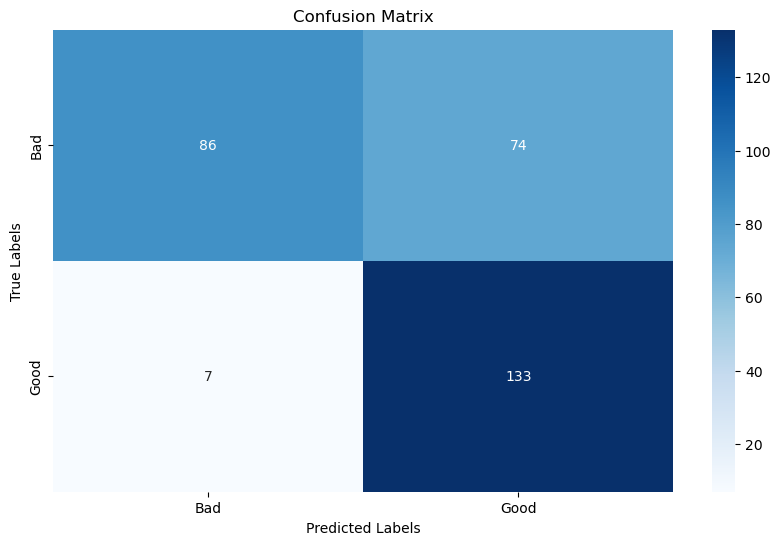

In [161]:
# Create a confusion matrix
KNNconf_matrix = confusion_matrix(Ny_test, K_y_pred)
    
# Plot confusion matrix
plt.figure(figsize=(10, 6))
sb.heatmap(KNNconf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=Kngrid_search.classes_, yticklabels=Kngrid_search.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

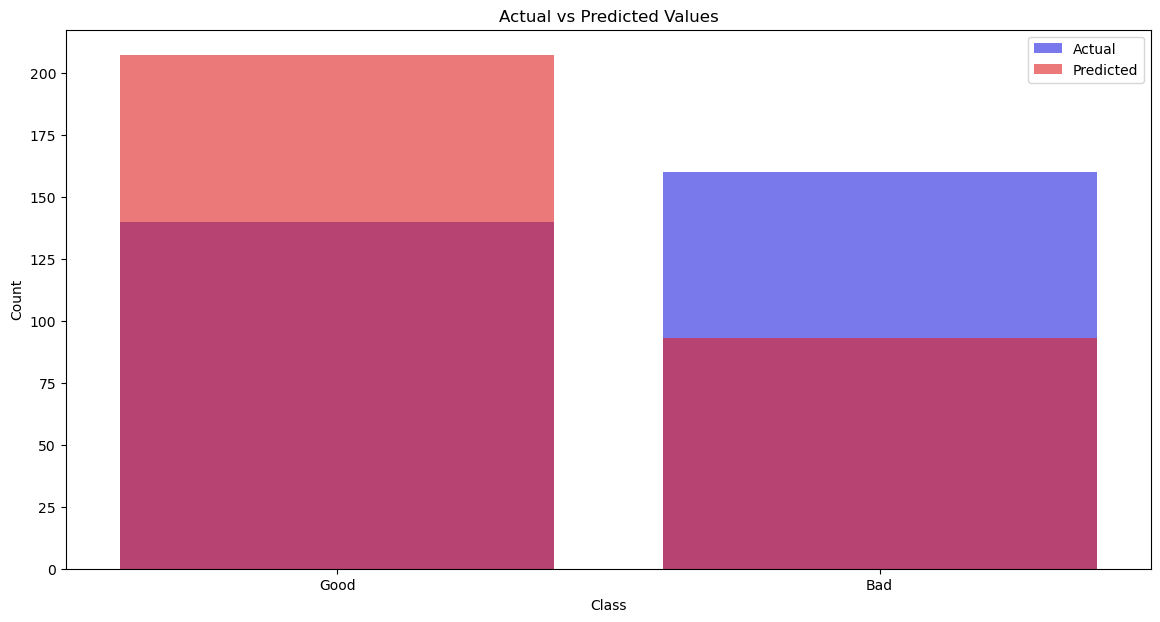

In [162]:
# Ensure Ny_test is a 1-dimensional array
K_y_pred_array = K_y_pred.flatten()

# Create a DataFrame with actual and predicted values
Kresults_df = pd.DataFrame({'Actual': Ny_test_array, 'Predicted': K_y_pred_array})
    
    
# Plot actual and predicted values
plt.figure(figsize=(14, 7))
sb.countplot(x='Actual', data=Kresults_df, color='blue', alpha=0.6, label='Actual')
sb.countplot(x='Predicted', data=Kresults_df, color='red', alpha=0.6, label='Predicted')
plt.title('Actual vs Predicted Values')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend()
plt.show()

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Sample Data Preparation (Simulating from the image data provided)
data = {
    'GovtFunding': [100.0, 18.0, 100.0, 94.0, 85.0, 100.0, 25.0, 27.0, 90.0, 5.0],
    'TeachersWithBSc': [11, 5, 2, 1, 2, 68, 59, 58, 54, 40],
    'LocationOfSchool': [1, 4, 2, 3, 1, 1, 2, 3, 2, 2],
    'DigitalDevices': [1, 4, 4, 3, 1, 1, 2, 3, 4, 3],
    'StudyRoomBySchool': [2, 1, 3, 3, 2, 3, 1, 2, 2, 3],
    'CLSIZE': [18, 23, 48, 28, 23, 23, 28, 23, 28, 23],
    'ExtraActivitiesOffered': [1, 2, 2, 1, 1, 2, 2, 2, 2, 2],
    'GoodPerformance': [1, 0, 1, 1, 1, 1, 0, 0, 1, 0]  # This is the target variable
}

# Creating DataFrame
df = pd.DataFrame(data)

# Splitting the data into features and target
X = df.drop(columns=['GoodPerformance'])
y = df['GoodPerformance']

# Splitting into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling for deep learning
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Sequential Model
deep_model = Sequential()
deep_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
deep_model.add(Dense(32, activation='relu'))
deep_model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

# Compile the model
deep_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
deep_model.fit(X_train_scaled, y_train, epochs=50, batch_size=10, verbose=1)

# Evaluate the model on test data
deep_predictions = (deep_model.predict(X_test_scaled) > 0.5).astype("int32")

# Evaluate Accuracy
from sklearn.metrics import accuracy_score
deep_accuracy = accuracy_score(y_test, deep_predictions)
print(f"Deep Learning Model Accuracy: {deep_accuracy}")


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4286 - loss: 0.7265
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4286 - loss: 0.7143
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4286 - loss: 0.7026
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4286 - loss: 0.6913
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4286 - loss: 0.6802
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4286 - loss: 0.6696
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4286 - loss: 0.6594
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4286 - loss: 0.6494
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5714 - loss: 0.6399
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8571 - loss: 0.6307
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8571 - loss: 0.6218
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8571 - loss: 0.6129
Epo

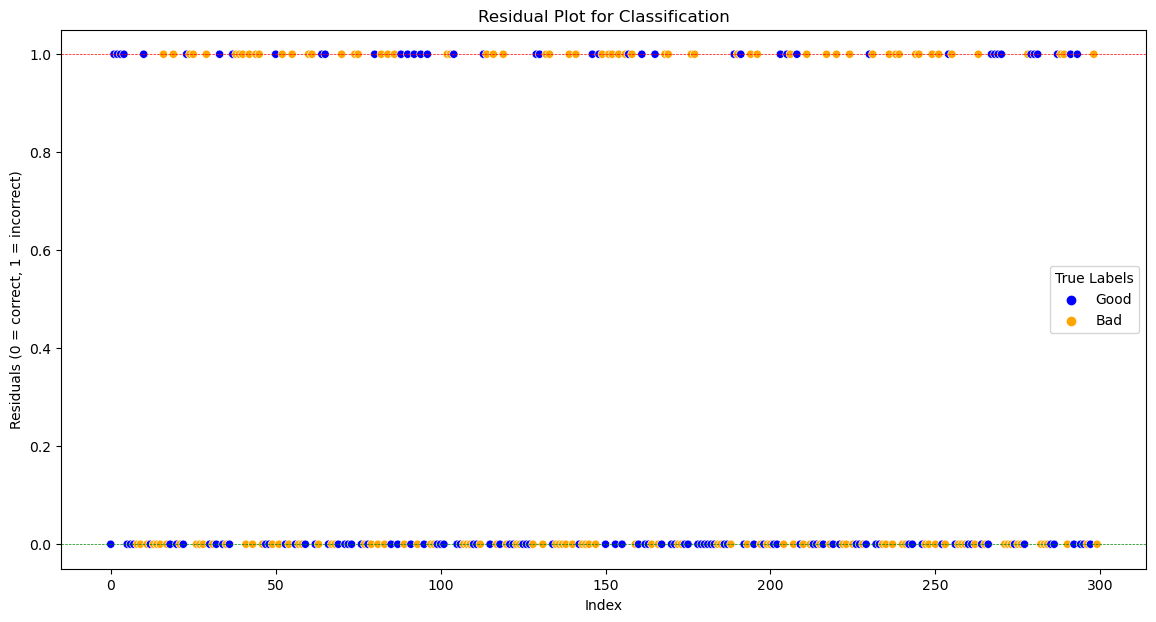

In [57]:
# Convert Ny_test to a numpy array
Ny_test_array = Ny_test['Classification'].values

# Calculate residuals as differences between actual and predicted values
# Here we define residuals as 0 for correct predictions and 1 for incorrect predictions
residuals = np.where(Ny_test_array == K_y_pred, 0, 1)


# Create a DataFrame to hold true labels, predicted labels, and residuals
residuals_df = pd.DataFrame({
    'True Labels': Ny_test_array,
    'Predicted Labels': K_y_pred,
    'Residuals': residuals
})

# Plot the residuals
plt.figure(figsize=(14, 7))
sb.scatterplot(data=residuals_df, x=range(len(residuals_df)), y='Residuals', hue='True Labels', palette=['blue', 'orange'])
plt.axhline(0, color='green', linestyle='--', linewidth=0.5)
plt.axhline(1, color='red', linestyle='--', linewidth=0.5)
plt.xlabel('Index')
plt.ylabel('Residuals (0 = correct, 1 = incorrect)')
plt.title('Residual Plot for Classification')
plt.legend(title='True Labels')
plt.show()

In [52]:
# Calculate confusion matrix
conf_matrix = confusion_matrix(Ny_test_array, K_y_pred)
conf_matrix

array([[98, 62],
       [43, 97]], dtype=int64)

In [163]:
# Mapping dictionary
mapping = {'Good': 1, 'Bad': 2}

# Convert the array using the mapping dictionary
K_y_pred_mapped = np.vectorize(mapping.get)(K_y_pred)
D_y_pred_mapped = np.vectorize(mapping.get)(D_y_pred)
R_y_pred_mapped = np.vectorize(mapping.get)(New_y_pred)
Ny_test_array_mapped = np.vectorize(mapping.get)(Ny_test_array)

In [164]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate RMSE for KNN
Krmse = np.sqrt(mean_squared_error(Ny_test_array_mapped, K_y_pred_mapped))
# Calculate MAE for KNN
Kmae = mean_absolute_error(Ny_test_array_mapped, K_y_pred_mapped)

# Calculate RMSE for DecisionTree
Drmse = np.sqrt(mean_squared_error(Ny_test_array_mapped, D_y_pred_mapped))
# Calculate MAE for DecisionTree
Dmae = mean_absolute_error(Ny_test_array_mapped, D_y_pred_mapped)

# Calculate RMSE for RandomForest
Rrmse = np.sqrt(mean_squared_error(Ny_test_array_mapped, R_y_pred_mapped))
# Calculate MAE for RandomForest
Rmae = mean_absolute_error(Ny_test_array_mapped, R_y_pred_mapped)
    
# Create a dictionary to hold the data
data = {
    'Model Evaluation': ['KNN', 'DecisionTree', 'RandomForest'],
    'RMSE': [Krmse, Drmse, Rrmse],
    'MAE': [Kmae, Dmae, Rmae]
}

# Create a DataFrame from the dictionary
df = pd.DataFrame(data)

# Print the DataFrame in a formatted manner
print(df.to_string(index=False))

Model Evaluation     RMSE      MAE
             KNN 0.519615 0.270000
    DecisionTree 0.538516 0.290000
    RandomForest 0.496655 0.246667


In [258]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=10)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(600, 2)
(400, 2)
(600, 1)
(400, 1)


In [217]:
coeff_parameter = pd.DataFrame(model.coef_[0],X.columns,columns=['Coefficient']).sort_values(by ='Coefficient', ascending = False)
coeff_parameter

,Coefficient
TeachersWithBSc,0.220856
GovtFunding,0.072768
